In [3]:
import duckdb
import pandas as pd

duckdb_path ="data/sakila.duckdb"

with duckdb.connect(duckdb_path) as conn, open("sql/load_sakila.sql") as ingest_script:
    conn.sql(ingest_script.read())
    
    films = conn.sql("FROM film;").df()
    
films



,film_id,title,description,release_year,language_id,original_language_id,rental_duration,rental_rate,length,replacement_cost,rating,special_features,last_update
0,1,ACADEMY DINOSAUR,A Epic Drama of a Feminist And a Mad Scientist...,2006,1,<NA>,6,0.99,86,20.99,PG,"Deleted Scenes,Behind the Scenes",2021-03-06 15:52:00
1,2,ACE GOLDFINGER,A Astounding Epistle of a Database Administrat...,2006,1,<NA>,3,4.99,48,12.99,G,"Trailers,Deleted Scenes",2021-03-06 15:52:00
2,3,ADAPTATION HOLES,A Astounding Reflection of a Lumberjack And a ...,2006,1,<NA>,7,2.99,50,18.99,NC-17,"Trailers,Deleted Scenes",2021-03-06 15:52:00
3,4,AFFAIR PREJUDICE,A Fanciful Documentary of a Frisbee And a Lumb...,2006,1,<NA>,5,2.99,117,26.99,G,"Commentaries,Behind the Scenes",2021-03-06 15:52:00
4,5,AFRICAN EGG,A Fast-Paced Documentary of a Pastry Chef And ...,2006,1,<NA>,6,2.99,130,22.99,G,Deleted Scenes,2021-03-06 15:52:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,YOUNG LANGUAGE,A Unbelieveable Yarn of a Boat And a Database ...,2006,1,<NA>,6,0.99,183,9.99,G,"Trailers,Behind the Scenes",2021-03-06 15:52:08
996,997,YOUTH KICK,A Touching Drama of a Teacher And a Cat who mu...,2006,1,<NA>,4,0.99,179,14.99,NC-17,"Trailers,Behind the Scenes",2021-03-06 15:52:08
997,998,ZHIVAGO CORE,A Fateful Yarn of a Composer And a Man who mus...,2006,1,<NA>,6,0.99,105,10.99,NC-17,Deleted Scenes,2021-03-06 15:52:08
998,999,ZOOLANDER FICTION,A Fateful Reflection of a Waitress And a Boat ...,2006,1,<NA>,5,2.99,101,28.99,R,"Trailers,Deleted Scenes",2021-03-06 15:52:08


In [4]:
import duckdb 
import pandas as pd 

# Anslut till DuckDB-databasen
db_path = "data/sakila.duckdb"
conn = duckdb.connect(db_path)

query = """
SELECT
    title,
    length
FROM film
WHERE length > 180
ORDER BY length DESC
"""

df_long_movies = conn.execute(query).df()
df_long_movies



,title,length
0,WORST BANGER,185
1,CHICAGO NORTH,185
2,CONTROL ANTHEM,185
3,DARN FORRESTER,185
4,SWEET BROTHERHOOD,185
5,GANGS PRIDE,185
6,HOME PITY,185
7,SOLDIERS EVOLUTION,185
8,POND SEATTLE,185
9,MUSCLE BRIGHT,185


In [5]:
df_love_movies = conn.execute("""
SELECT title, length
FROM film
WHERE title ILIKE '%love%'
""").df()

df_love_movies



,title,length
0,GRAFFITI LOVE,117
1,IDAHO LOVE,172
2,IDENTITY LOVER,119
3,INDIAN LOVE,135
4,LAWRENCE LOVE,175
5,LOVE SUICIDES,181
6,LOVELY JINGLE,65
7,LOVER TRUMAN,75
8,LOVERBOY ATTACKS,162
9,STRANGELOVE DESIRE,103


In [6]:
query = """
SELECT
    MIN(length)    AS shortest,
    AVG(length)    AS average,
    MEDIAN(length) AS median,
    MAX(length)    AS longest
FROM film
"""
df_length_stats = conn.execute(query).df()
df_length_stats


,shortest,average,median,longest
0,46,115.272,114.0,185


In [7]:
query = """
SELECT
    title,
    rental_rate,
    rental_duration,
    rental_rate / rental_duration AS cost_per_day
FROM film
ORDER BY cost_per_day DESC
LIMIT 10
"""
df_expensive_per_day = conn.execute(query).df()
df_expensive_per_day




,title,rental_rate,rental_duration,cost_per_day
0,BACKLASH UNDEFEATED,4.99,3,1.663333
1,BILKO ANONYMOUS,4.99,3,1.663333
2,BEAST HUNCHBACK,4.99,3,1.663333
3,AUTUMN CROW,4.99,3,1.663333
4,ACE GOLDFINGER,4.99,3,1.663333
5,CARIBBEAN LIBERTY,4.99,3,1.663333
6,BEHAVIOR RUNAWAY,4.99,3,1.663333
7,CASPER DRAGONFLY,4.99,3,1.663333
8,AMERICAN CIRCUS,4.99,3,1.663333
9,CASUALTIES ENCINO,4.99,3,1.663333


In [9]:
df_top_actors = conn.execute("""
SELECT
    a.first_name || ' ' || a.last_name AS actor,
    COUNT(*) AS movie_count
FROM actor a
JOIN film_actor fa ON a.actor_id = fa.actor_id
GROUP BY actor
ORDER BY movie_count DESC
LIMIT 10
""").df()

df_top_actors




,actor,movie_count
0,SUSAN DAVIS,54
1,GINA DEGENERES,42
2,WALTER TORN,41
3,MARY KEITEL,40
4,MATTHEW CARREY,39
5,SANDRA KILMER,37
6,SCARLETT DAMON,36
7,GROUCHO DUNST,35
8,ANGELA WITHERSPOON,35
9,VIVIEN BASINGER,35


In [10]:
df_rating = conn.execute("""
SELECT rating, COUNT(*) AS count
FROM film
GROUP BY rating
ORDER BY count DESC
""").df()

df_rating



,rating,count
0,PG-13,223
1,NC-17,210
2,R,195
3,PG,194
4,G,178


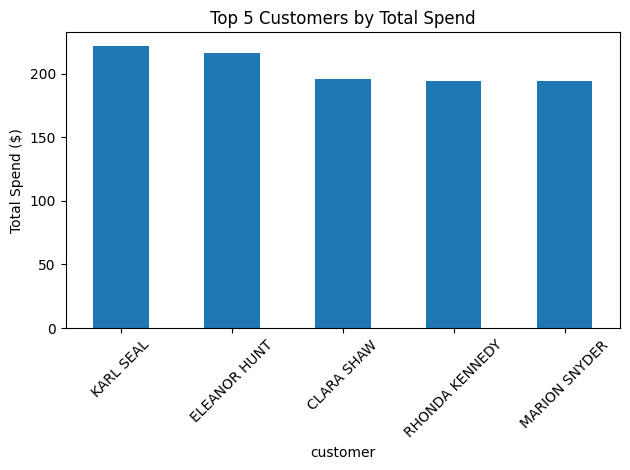

In [15]:
import matplotlib.pyplot as plt

query = """
SELECT
    c.name AS category,
    COUNT(fc.film_id) AS number_of_movies
FROM category c
JOIN film_category fc
    ON c.category_id = fc.category_id
GROUP BY category
ORDER BY number_of_movies DESC
"""
df_top_customers

df_top_customers.plot(
    kind="bar",
    x="customer",
    y="total_spend",
    legend=False,
    title="Top 5 Customers by Total Spend"
)

plt.ylabel("Total Spend ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [12]:
df_length_stats = conn.execute("""
SELECT
    MIN(length) AS shortest,
    AVG(length) AS average,
    MEDIAN(length) AS median,
    MAX(length) AS longest
FROM film
""").df()

df_length_stats




,shortest,average,median,longest
0,46,115.272,114.0,185


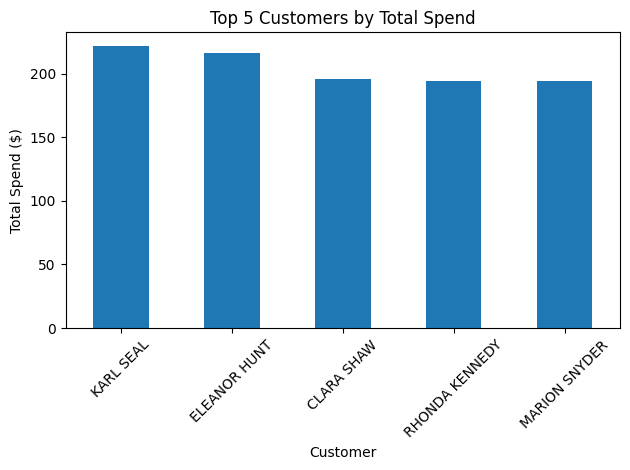

In [13]:
import matplotlib.pyplot as plt


query = """
SELECT
    c.first_name || ' ' || c.last_name AS customer,
    SUM(p.amount) AS total_spend
FROM customer c
JOIN payment p
    ON c.customer_id = p.customer_id
GROUP BY customer
ORDER BY total_spend DESC
LIMIT 5
"""

df_top_customers = conn.execute(query).df()
df_top_customers


df_top_customers.plot(
    kind="bar",
    x="customer",
    y="total_spend",
    legend=False,
    title="Top 5 Customers by Total Spend"
)

plt.xlabel("Customer")
plt.ylabel("Total Spend ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



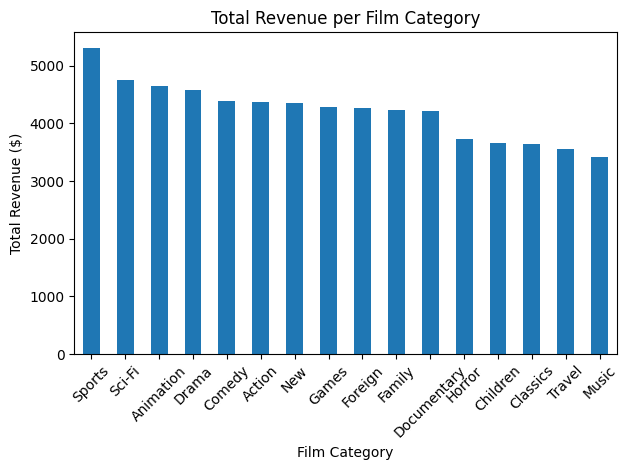

In [14]:


query = """
SELECT
    c.name AS category,
    SUM(p.amount) AS total_revenue
FROM category c
JOIN film_category fc
    ON c.category_id = fc.category_id
JOIN film f
    ON fc.film_id = f.film_id
JOIN inventory i
    ON f.film_id = i.film_id
JOIN rental r
    ON i.inventory_id = r.inventory_id
JOIN payment p
    ON r.rental_id = p.rental_id
GROUP BY category
ORDER BY total_revenue DESC
"""
df_category_revenue = conn.execute(query).df()
df_category_revenue

df_category_revenue.plot(
    kind="bar",
    x="category",
    y="total_revenue",
    legend=False,
    title="Total Revenue per Film Category"
)

plt.xlabel("Film Category")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
